# E-Commerce Data Analysis
This notebook addresses various analytical questions on the e-commerce dataset.
The code is written with detailed comments to make the logic easy to understand for laymen.


In [1]:
# Import necessary libraries for our analysis
import pandas as pd # pandas is used to load and manipulate the tabular data
import matplotlib.pyplot as plt # matplotlib is for creating static charts and graphs
import seaborn as sns # seaborn makes our charts look better and provides advanced plots
import numpy as np # numpy is used for numerical calculations
import warnings
warnings.filterwarnings('ignore') # Ignore warnings for cleaner output

# Load the dataset into a pandas DataFrame (which is like an Excel table in Python)
# We assume the file is in the same directory as the notebook
df = pd.read_csv('Clean_Ecommerce_data.csv')

# Convert 'created_at' column to proper datetime format so we can analyze dates easily
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

# Display the top 5 rows to make sure our data loaded correctly
df.head()


,Unnamed: 0,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,Category,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
0,0,211131,complete,2016-07-01,kreations_YI 06-L,1950,1,1950,100147443,Women's Fashion,...,cod,2016-07-01,#REF!,"1,950",2016,7,2016-7,7-2016,FY17,1
1,1,211133,canceled,2016-07-01,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240,1,240,100147444,Beauty & Grooming,...,cod,2016-07-01,Gross,240,2016,7,2016-7,7-2016,FY17,2
2,2,211134,canceled,2016-07-01,Ego_UP0017-999-MR0,2450,1,2450,100147445,Women's Fashion,...,cod,2016-07-01,Gross,"2,450",2016,7,2016-7,7-2016,FY17,3
3,3,211135,complete,2016-07-01,kcc_krone deal,360,1,60,100147446,Beauty & Grooming,...,cod,2016-07-01,Net,360,2016,7,2016-7,7-2016,FY17,4
4,4,211136,order_refunded,2016-07-01,BK7010400AG,555,2,1110,100147447,Soghaat,...,cod,2016-07-01,Valid,"1,110",2016,7,2016-7,7-2016,FY17,5


### 1. What is the best-selling category?


The best-selling category is 'Mobiles & Tablets' with 110407 items sold.


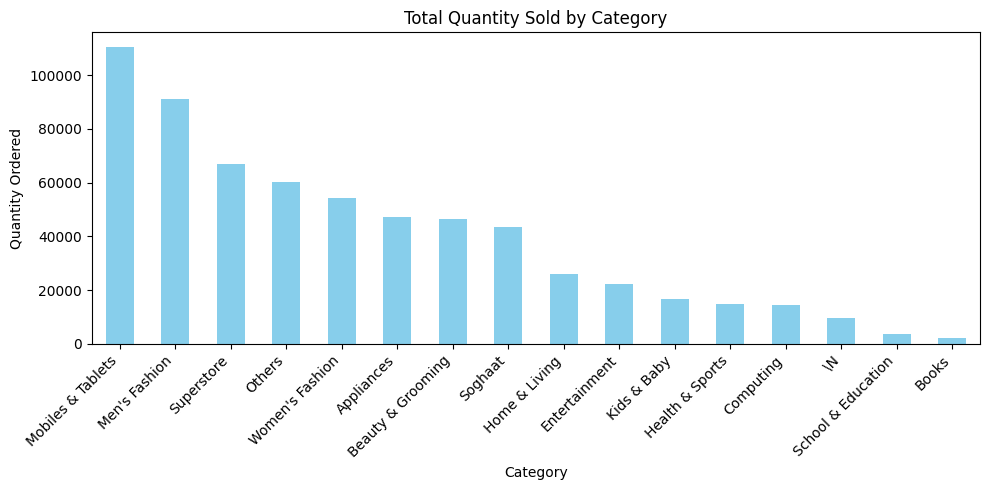

In [2]:
# Group the data by 'Category' and calculate the total 'qty_ordered' (quantity ordered) for each
# 'sum()' adds up all the quantities for each category
category_sales = df.groupby('Category')['qty_ordered'].sum()

# Sort the results in descending order (highest to lowest) to easily find the top seller
category_sales = category_sales.sort_values(ascending=False)

# Get the first item (the highest value) which is our best-selling category
best_category = category_sales.index[0]
best_qty = category_sales.iloc[0]

# Print the result clearly
print(f"The best-selling category is '{best_category}' with {best_qty} items sold.")

# Optional: Plot a bar chart to visualize sales per category
plt.figure(figsize=(10, 5)) # Set the size of the image
category_sales.plot(kind='bar', color='skyblue') # Create a bar chart
plt.title('Total Quantity Sold by Category') # Add a title
plt.ylabel('Quantity Ordered') # Label the y-axis
plt.xlabel('Category') # Label the x-axis
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels so they don't overlap
plt.tight_layout() # Automatically adjust layout to fit everything
plt.show() # Display the plot


### 2. Visualize payment method and order status frequency


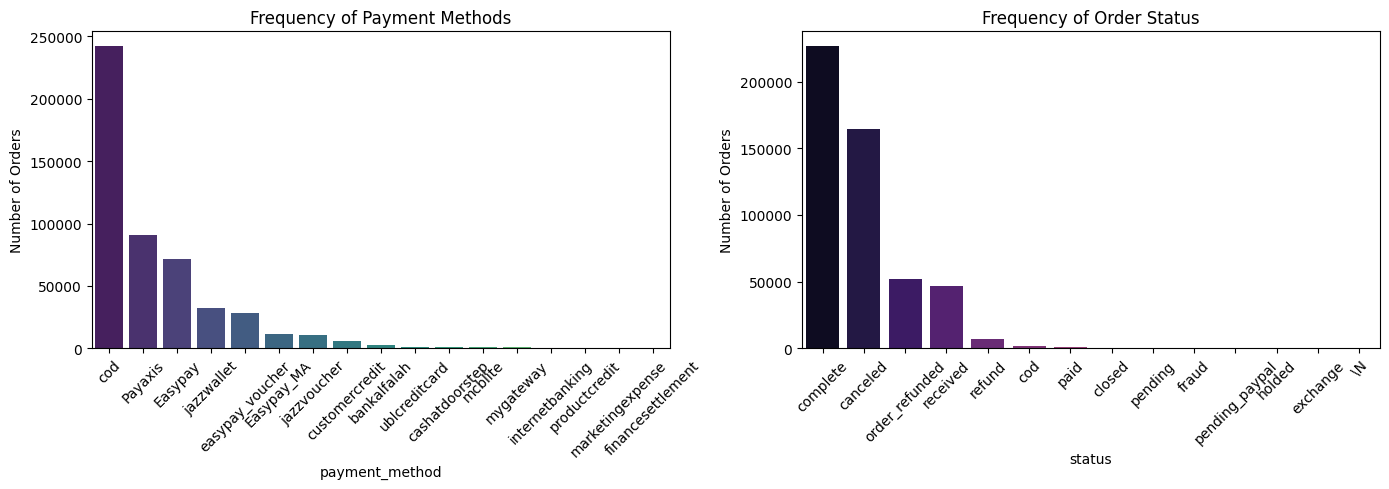

In [3]:
# Set up a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Payment Method Frequency
# countplot automatically counts the occurrences of each category
sns.countplot(data=df, x='payment_method', ax=axes[0], palette='viridis', order=df['payment_method'].value_counts().index)
axes[0].set_title('Frequency of Payment Methods') # Add title
axes[0].set_ylabel('Number of Orders') # Add Y label
axes[0].tick_params(axis='x', rotation=45) # Rotate X labels

# Plot 2: Order Status Frequency
sns.countplot(data=df, x='status', ax=axes[1], palette='magma', order=df['status'].value_counts().index)
axes[1].set_title('Frequency of Order Status') # Add title
axes[1].set_ylabel('Number of Orders') # Add Y label
axes[1].tick_params(axis='x', rotation=45) # Rotate X labels

# Adjust the spacing between plots and show them
plt.tight_layout()
plt.show()


### 3. Correlation between payment method and order status


Cross-Tabulation of Payment Method vs Order Status:


status,\N,canceled,closed,cod,complete,exchange,fraud,holded,order_refunded,paid,pending,pending_paypal,received,refund
payment_method,,,,,,,,,,,,,,
Easypay,0,45158,16,0,19018,0,0,0,2255,160,0,0,4446,655
Easypay_MA,0,7621,0,0,3025,0,0,0,257,15,0,0,594,122
Payaxis,0,57127,70,0,22685,0,9,0,3605,272,0,0,6379,501
bankalfalah,0,1560,1,0,166,0,0,0,45,0,0,0,565,1
cashatdoorstep,0,5,0,0,674,0,0,0,30,0,0,0,5,18
cod,4,18568,301,1787,142654,4,0,6,43344,0,0,7,30340,5004
customercredit,0,46,24,0,3851,0,0,0,1110,24,1,0,744,207
easypay_voucher,0,10988,1,0,15871,0,0,0,410,2,30,0,847,205
financesettlement,0,1,0,0,9,0,0,0,1,0,0,0,0,4


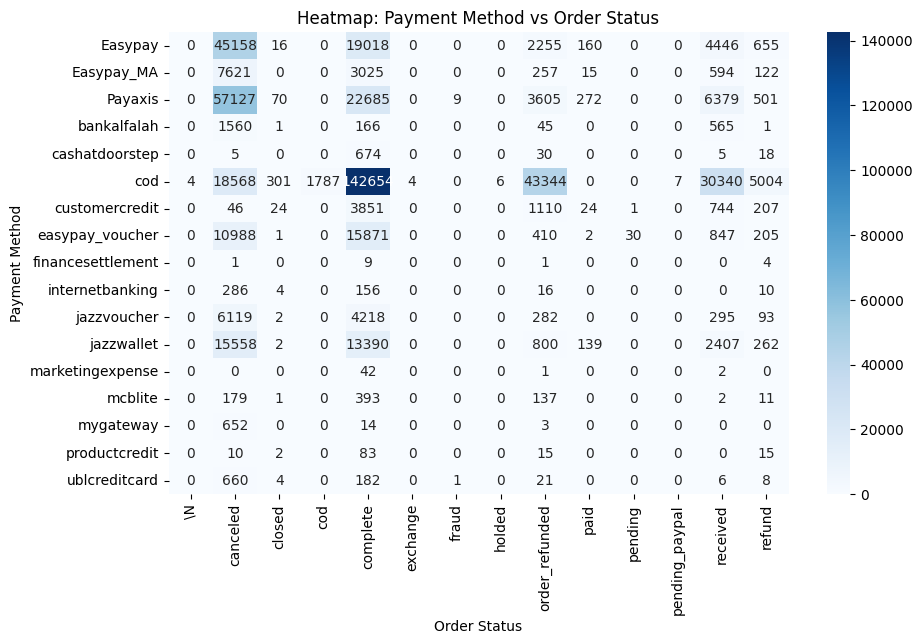

In [4]:
# Since payment method and order status are categorical (text) variables, standard numerical correlation doesn't work.
# Instead, we use a cross-tabulation (contingency table) to see how often each payment method results in each status.

# Create a cross-table counting rows for each combination of payment method and order status
cross_tab = pd.crosstab(df['payment_method'], df['status'])

# Display the raw table
print("Cross-Tabulation of Payment Method vs Order Status:")
display(cross_tab)

# Visualize the cross-tabulation using a heatmap
plt.figure(figsize=(10, 6)) # Set chart size
# Create heatmap, 'annot=True' puts the numbers inside the colored boxes, 'cmap' sets the color scheme
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues') 
plt.title('Heatmap: Payment Method vs Order Status') # Title
plt.ylabel('Payment Method') # Y label
plt.xlabel('Order Status') # X label
plt.show()

# Conclusion comment:
# A strong "correlation" here means a specific payment method is heavily linked to a specific status 
# (e.g., Cash on Delivery (COD) might have higher cancellation rates compared to prepaid).


### 4. Correlation between order date and item category


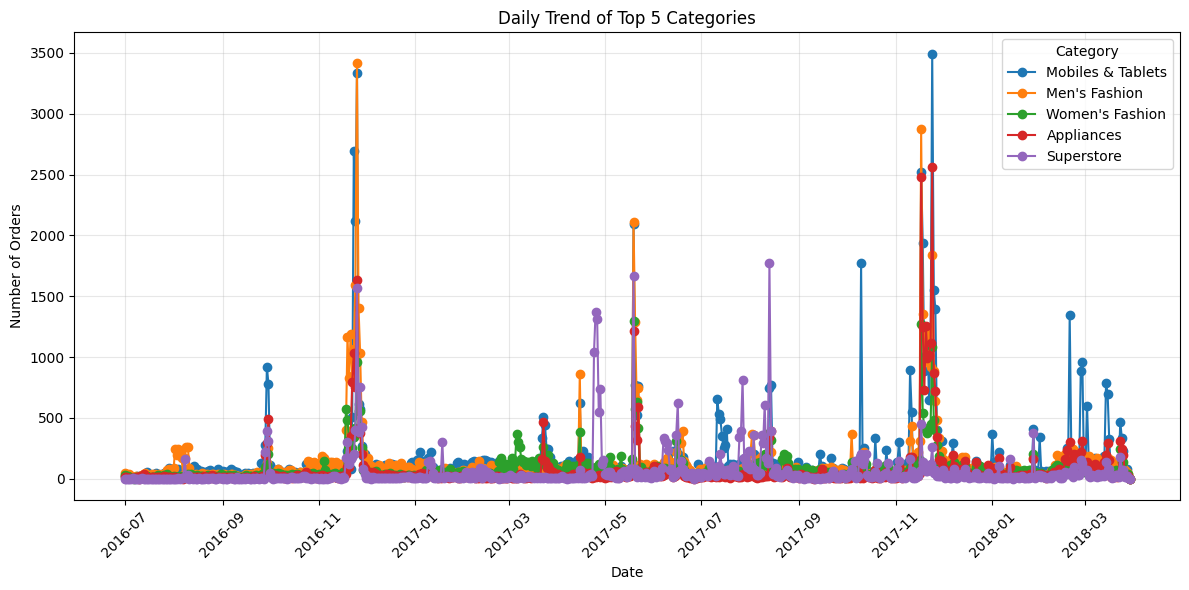

In [5]:
# To see how item categories behave over time, we will look at daily order counts for each category.

# Create a cross-tabulation of order date (created_at) vs Category
date_cat_trend = pd.crosstab(df['created_at'], df['Category'])

# We will plot a line chart to show the trend of top 5 categories over time to avoid clutter
# Find the top 5 categories by total volume to filter our chart
top_5_cats = df['Category'].value_counts().head(5).index

# Plot the trends for only the top 5 categories
plt.figure(figsize=(12, 6)) # Chart size
for cat in top_5_cats:
    # Plot a line for each category over time
    plt.plot(date_cat_trend.index, date_cat_trend[cat], marker='o', label=cat)

plt.title('Daily Trend of Top 5 Categories') # Title
plt.xlabel('Date') # X label
plt.ylabel('Number of Orders') # Y label
plt.legend(title='Category') # Add a legend to identify the lines
plt.grid(True, alpha=0.3) # Add a faint grid for readability
plt.xticks(rotation=45) # Rotate dates on X axis
plt.tight_layout()
plt.show()


### 5. Find any hidden patterns that are counter-intuitive for a layman


Average Price by Order Status:


status
fraud             62694.400000
pending           30056.645161
canceled           9144.269919
closed             6042.738318
order_refunded     5364.731579
complete           4244.969390
refund             1936.876476
exchange           1441.000000
received           1321.961850
paid                832.236928
pending_paypal      795.000000
cod                 785.803022
holded              312.333333
\N                   39.000000
Name: price, dtype: float64

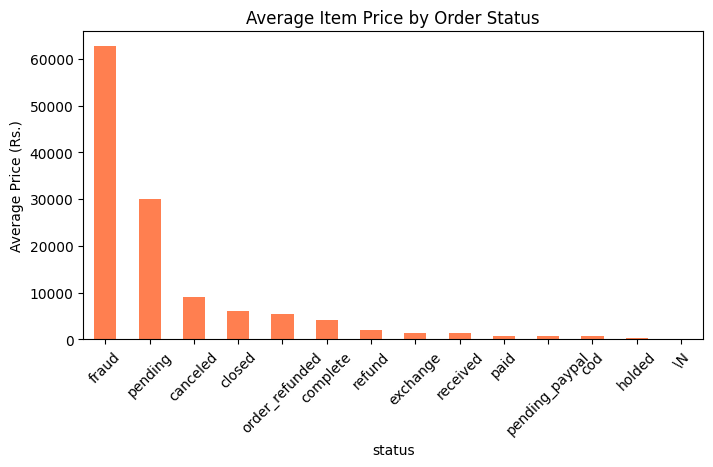


Percentage of Order Status by Discount Presence (Row percentages):


status,\N,canceled,closed,cod,complete,exchange,fraud,holded,order_refunded,paid,pending,pending_paypal,received,refund
has_discount,,,,,,,,,,,,,,
False,0.001255,27.265711,0.107928,0.536818,46.289022,0.001255,0.003137,0.001882,14.142064,0.042983,0.001255,0.002196,9.979920,1.624573
True,0.000000,42.842479,0.046356,0.041941,43.537813,0.000000,0.000000,0.000000,4.004790,0.262130,0.014900,0.000000,8.180102,1.069489


In [6]:
# Let's explore cancellations. A layman might think expensive items get canceled more often.
# Let's check the average price of canceled orders vs completed orders.

# Convert price to numeric, handling errors
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Calculate average price grouped by order status
avg_price_by_status = df.groupby('status')['price'].mean().sort_values(ascending=False).dropna()

print("Average Price by Order Status:")
display(avg_price_by_status)

# Plot this finding
plt.figure(figsize=(8, 4))
avg_price_by_status.plot(kind='bar', color='coral')
plt.title('Average Item Price by Order Status')
plt.ylabel('Average Price (Rs.)')
plt.xticks(rotation=45)
plt.show()

# Also, let's check if Discounts lead to fewer cancellations (Counter-intuitive: Sometimes heavy discounts attract impulsive buys that get canceled later).
# We check the percentage of orders canceled for discounted vs non-discounted orders
df['discount_amount'] = pd.to_numeric(df['discount_amount'], errors='coerce').fillna(0)
df['has_discount'] = df['discount_amount'] > 0
discount_status = pd.crosstab(df['has_discount'], df['status'], normalize='index') * 100

print("\nPercentage of Order Status by Discount Presence (Row percentages):")
display(discount_status)

# Conclusion pattern:
# Analyzing these can show if "has_discount" unexpectedly leads to higher cancellation or refund rates, 
# or if cheaper items actually face more cancellations than expensive items.


### 6. Can we predict number of orders, or item category or number of customers/amount in advance?


Predicted number of orders for the next 7 days:
2018-03-30: 1045 orders
2018-03-31: 1046 orders
2018-04-01: 1047 orders
2018-04-02: 1047 orders
2018-04-03: 1048 orders
2018-04-04: 1049 orders
2018-04-05: 1050 orders


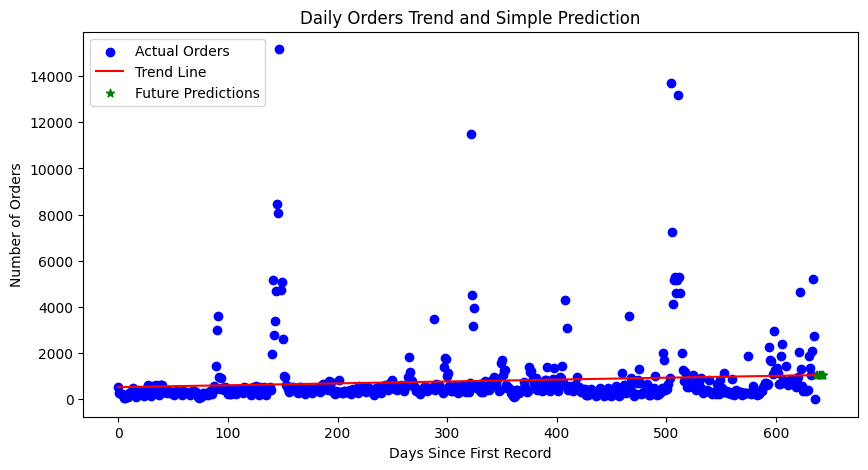

In [7]:
# Yes, we can use simple Time Series forecasting or Machine Learning regression to predict future values.
# Here, we will build a VERY simple Linear Regression model to predict the total number of daily orders.

from sklearn.linear_model import LinearRegression # Import the algorithm
import datetime as dt

# Group data by date to get daily order counts
daily_orders = df.groupby('created_at').size().reset_index(name='order_count')

# Machine learning models need numbers, not dates. So we convert dates to "days since start"
daily_orders['days_since_start'] = (daily_orders['created_at'] - daily_orders['created_at'].min()).dt.days

# Drop NaNs just in case
daily_orders = daily_orders.dropna(subset=['days_since_start'])

# X is our input feature (days since start), Y is what we want to predict (order_count)
X = daily_orders[['days_since_start']] 
y = daily_orders['order_count']

# Create the model and train (fit) it with our data
model = LinearRegression()
model.fit(X, y)

# Let's predict orders for the next 7 days
last_day = daily_orders['days_since_start'].max()
# Create a dataframe for the next 7 days
future_days = pd.DataFrame({'days_since_start': range(int(last_day) + 1, int(last_day) + 8)})

# Make predictions
future_predictions = model.predict(future_days)

# Print results
print("Predicted number of orders for the next 7 days:")
for i, pred in enumerate(future_predictions):
    # Calculate the actual future date for display
    future_date = daily_orders['created_at'].max() + pd.Timedelta(days=i+1)
    print(f"{future_date.date()}: {int(pred)} orders")

# Plot historical data vs predictions
plt.figure(figsize=(10, 5))
# Plot actual historical orders
plt.scatter(daily_orders['days_since_start'], daily_orders['order_count'], color='blue', label='Actual Orders')
# Plot the trend line (what the model learned)
plt.plot(daily_orders['days_since_start'], model.predict(X), color='red', label='Trend Line')
# Plot the future predictions
plt.scatter(future_days['days_since_start'], future_predictions, color='green', label='Future Predictions', marker='*')

plt.title('Daily Orders Trend and Simple Prediction')
plt.xlabel('Days Since First Record')
plt.ylabel('Number of Orders')
plt.legend()
plt.show()

# Note: This is a basic model. Real-world forecasting would use advanced time-series models (like ARIMA or Prophet) 
# and consider seasonality (like weekends vs weekdays).
